# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy

# The Github Link: ***https://github.com/itmuvunyi/PCA***




### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

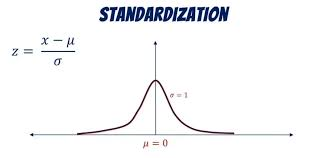


In [1]:
import numpy as np
import csv

# 1. LOAD AND PIVOT DATA (Pure Python & NumPy)
countries = []
indicators = []
data_dict = {}

# Parse the dataset into a dictionary
with open('ObservationData new.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        country = row['Country and Regions Name']
        indicator = row['Indicators Name']

        # Format the numbers (replace commas with decimals and handle missing data)
        val_str = row['1980'].replace(',', '.')
        try:
            val = float(val_str)
        except ValueError:
            val = np.nan

        if country not in data_dict:
            data_dict[country] = {}
            countries.append(country)

        if indicator not in indicators:
            indicators.append(indicator)

        data_dict[country][indicator] = val

# Convert dict to a 2D list, then to a NumPy array
raw_data = []
for country in countries:
    row_data = [data_dict[country].get(ind, np.nan) for ind in indicators]
    raw_data.append(row_data)

# Extract numeric data matrix
numeric_data = np.array(raw_data, dtype=float)

# 2. HANDLE MISSING VALUES (Mean Imputation using pure NumPy)
col_means = np.nanmean(numeric_data, axis=0)
nan_indices = np.where(np.isnan(numeric_data))
numeric_data[nan_indices] = np.take(col_means, nan_indices[1])

# 3. STANDARDIZE THE DATA
# Formula: Z = (X - \mu) / \sigma
mean_vals = np.mean(numeric_data, axis=0)
std_vals = np.std(numeric_data, axis=0)

# Prevent division by zero for columns with 0 variance
std_vals[std_vals == 0] = 1.0

standardized_data = (numeric_data - mean_vals) / std_vals
standardized_data[:5]

array([[ 0.        ,  0.        ,  0.19548795,  0.24896706,  0.14237473,
         0.22390224,  0.12033604,  0.68466105, -0.37891784, -0.36903653,
         0.32285948,  0.30372806, -0.36839872, -0.08641578, -0.40088967,
         1.82010527, -1.21372519, -0.86581654,  0.65069427, -0.10980876,
         1.94117613,  0.66172044,  0.28854933,  2.3076177 ,  1.21563458,
         0.1509891 ,  0.3223351 ,  0.5232835 ,  0.        ],
       [ 0.        ,  0.        , -0.24928287, -0.30127789, -0.30613582,
        -0.11370163, -0.3560924 , -0.35233478, -0.27641047, -0.4692832 ,
        -0.24763244, -0.30138849,  0.13489937,  3.21193396, -1.08000734,
        -0.8481495 ,  0.7368458 , -2.17933246,  1.94668142, -0.04123801,
         0.14595415, -0.29555091, -0.28242894, -0.77640201,  0.41136285,
         0.71166587,  0.17046549,  0.5800443 ,  0.        ],
       [ 0.        ,  0.        , -0.34719263, -0.35017421, -0.35565916,
        -0.37453214, -0.3495209 , -0.3687743 , -0.36894405, -0.34021579,
  

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [2]:
# Step 3: Calculate the Covariance Matrix
n_samples = standardized_data.shape[0]

# Using the matrix multiplication formula: C = (Z^T * Z) / (n - 1)
cov_matrix = (standardized_data.T @ standardized_data) / (n_samples - 1)

cov_matrix

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  1.01666667,  0.99633146,  0.99033905,
         1.00913948,  0.98218149,  1.00871887,  0.99478584,  0.98091667,
  

The key reason why we need to compute the covariance matrix is that it reveals all of the relationships and dependencies between all of the pairs of features in our dataset. The diagonal elements represent the variance of the different features and the off-diagonal elements represent the covariance between the different features. The eigendecomposition process of PCA is the basis of identifying the axes (principal components) on which the data has the largest variance in this matrix.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [3]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues:
 [ 1.29307896e+01  6.03017470e+00  1.77974457e+00  1.46148700e+00
  1.03870095e+00  8.28906313e-01  7.11587773e-01  5.09299567e-01
  3.66656055e-01  2.74741855e-01  2.02690067e-01  1.23313347e-01
  9.40806127e-02  3.81281322e-02  1.95041454e-02  1.29862328e-02
  4.73649792e-03  2.75328786e-03  1.70418369e-03  6.72741814e-04
  4.46596124e-04  1.61549839e-04  6.75336240e-05 -3.70880243e-16
  8.10523323e-18  2.43973789e-16  0.00000000e+00  0.00000000e+00
  0.00000000e+00]
Eigenvectors:
 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [4]:
# Step 5: Sort Principal Components
# Get indices that would sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]

# Sort eigenvectors and eigenvalues accordingly
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvalues = eigenvalues[sorted_indices]

print("Sorted Eigenvectors:\n", sorted_eigenvectors)

Sorted Eigenvectors:
 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00]
 [ 2.77220616e-0

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [5]:
# Step 6: Project Data onto Principal Components
# Dynamically select components based on a 90% variance threshold
explained_variances = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variances)
num_components = np.argmax(cumulative_variance >= 0.90) + 1

# Project data: Z_reduced = Z * W
reduced_data = np.dot(standardized_data, sorted_eigenvectors[:, :num_components])

print(reduced_data[:5])

[[ 3.69995344e-01 -2.82839251e-03  2.69022053e+00  9.25367738e-01
  -1.21029765e-01  1.49618073e+00]
 [-9.72976936e-01 -1.21326613e+00  4.44946934e-01  8.55243447e-01
  -3.61911795e+00 -1.28482293e+00]
 [-1.35851527e+00  4.22357148e-01 -4.79035164e-01 -6.08734780e-01
   9.98525150e-01  2.89684321e-01]
 [-1.14975338e+00 -2.03290556e+00  1.06828988e+00  8.77812845e-01
  -1.99126780e-01  7.62113924e-01]
 [-1.36749004e+00  7.10054101e-01 -9.15216825e-01 -1.35020212e+00
   1.35762333e+00  1.99280086e-02]]


### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [6]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')
print(reduced_data[:5])

Reduced Data Shape: (61, 6)
[[ 3.69995344e-01 -2.82839251e-03  2.69022053e+00  9.25367738e-01
  -1.21029765e-01  1.49618073e+00]
 [-9.72976936e-01 -1.21326613e+00  4.44946934e-01  8.55243447e-01
  -3.61911795e+00 -1.28482293e+00]
 [-1.35851527e+00  4.22357148e-01 -4.79035164e-01 -6.08734780e-01
   9.98525150e-01  2.89684321e-01]
 [-1.14975338e+00 -2.03290556e+00  1.06828988e+00  8.77812845e-01
  -1.99126780e-01  7.62113924e-01]
 [-1.36749004e+00  7.10054101e-01 -9.15216825e-01 -1.35020212e+00
   1.35762333e+00  1.99280086e-02]]


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

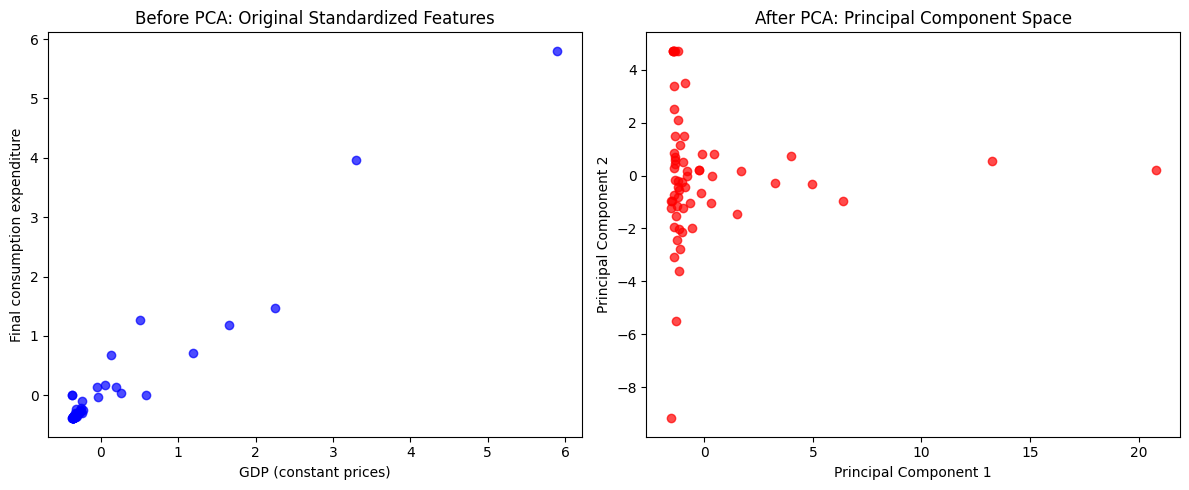

In [7]:
import matplotlib.pyplot as plt

# Step 8: Visualize Before and After PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot original data (first two features: GDP (constant) vs Final Consumption)
# Using columns index 2 and 4 from our generated dataset
ax1.scatter(standardized_data[:, 2], standardized_data[:, 4], c='blue', alpha=0.7)
ax1.set_title('Before PCA: Original Standardized Features')
ax1.set_xlabel('GDP (constant prices)')
ax1.set_ylabel('Final consumption expenditure')

# Plot reduced data after PCA (PC1 vs PC2)
ax2.scatter(reduced_data[:, 0], reduced_data[:, 1], c='red', alpha=0.7)
ax2.set_title('After PCA: Principal Component Space')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

***The “Before PCA” plot represents the data spread out across two arbitrary and physically meaningful variables, where they may be collinear. The "After PCA" plot displays the data on orthogonal axes (PC1 and PC2) that represent the directions of maximum variance. The resulting plot eliminates structure correlations between axes and optimally spreads the data points out to reveal the underlying mathematical structure of the data set.***

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

***The number of components was dynamically determined by calculating the cumulative explained variance and choosing a threshold of 90%. I'm keeping the above components only so I'm losing out on a bit of fine-grained, localized data variation (10% information loss), but getting rid of a lot of dimensional complexity. This tradeoff minimises computing overhead and helps to eliminate noise and retain the macro-trends.***

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

***Suppose the data is an African socio-economic dataset that includes variables such as GDP growth, population pressure, agricultural yield, etc. and that the main components are calculated excluding the lower variance components, then some localized anomalies are removed. The specific macroeconomic correlation of a continent or region is not captured by the PC1 and PC2, and the nuances of highly specific, independent events are lost—such as a temporary deterioration in agriculture in a particular country because of a drought in that country, and not the broader, continent- or region-wide correlation.***